In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')
train=pd.read_csv("/content/train.csv")#Load the Dataset
stores=pd.read_csv("/content/stores.csv")
features=pd.read_csv("/content/features.csv")
df=train.merge(stores,on='Store',how='left')
df=df.merge(features,on=['Store','Date'],how='left')
#here i do feature engineering for convert date str into date type and also create new column which have specific year month week
df['Date']=pd.to_datetime(df['Date'])#03-08-2010     -12
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
print("Dataset Shape:",df.shape)
print("Data Range:",df['Date'].min(), "to", df['Date'].max())
print("Stores:", df['Store'].nunique(), "| Departments:", df['Dept'].nunique())
print("\nSample:")
print(df.head(3))

Dataset Shape: (421570, 20)
Data Range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
Stores: 45 | Departments: 81

Sample:
   Store  Dept       Date  Weekly_Sales  IsHoliday_x Type    Size  \
0      1     1 2010-02-05      24924.50        False    A  151315   
1      1     1 2010-02-12      46039.49         True    A  151315   
2      1     1 2010-02-19      41595.55        False    A  151315   

   Temperature  Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  \
0        42.31       2.572        NaN        NaN        NaN        NaN   
1        38.51       2.548        NaN        NaN        NaN        NaN   
2        39.93       2.514        NaN        NaN        NaN        NaN   

   MarkDown5         CPI  Unemployment  IsHoliday_y  Year  Month  Week  
0        NaN  211.096358         8.106        False  2010      2     5  
1        NaN  211.242170         8.106         True  2010      2     6  
2        NaN  211.289143         8.106        False  2010      2     7  


In [29]:
df.describe()

,Store,Dept,Date,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,136727.915739,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,2010.968591,6.449510,25.826762
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,34875.000000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,2010.000000,1.000000,1.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,93638.000000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,2010.000000,4.000000,14.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,140167.000000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,2011.000000,6.000000,26.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,202505.000000,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,2012.000000,9.000000,38.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,219622.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,2012.000000,12.000000,52.000000
std,12.785297,30.492054,NaN,22711.183519,60980.583328,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,0.796876,3.243217,14.151887


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Type          421570 non-null  object        
 6   Size          421570 non-null  int64         
 7   Temperature   421570 non-null  float64       
 8   Fuel_Price    421570 non-null  float64       
 9   MarkDown1     150681 non-null  float64       
 10  MarkDown2     111248 non-null  float64       
 11  MarkDown3     137091 non-null  float64       
 12  MarkDown4     134967 non-null  float64       
 13  MarkDown5     151432 non-null  float64       
 14  CPI           421570 non-null  float64       
 15  Unemployment  421

In [31]:
# Identify departments at stockout risk
# A dept is "at risk" if forecast > actual last year's max supply

dept_summary = df.groupby('Dept')['Weekly_Sales'].agg(['mean','max','std']).reset_index()
dept_summary.columns = ['Dept', 'avg_sales', 'peak_sales', 'std_sales']

# Departments where peak exceeds avg by 2x = volatile = stockout risk
dept_summary['volatility'] = dept_summary['std_sales'] / dept_summary['avg_sales']
dept_summary['risk_flag'] = dept_summary['volatility'] > 0.5

at_risk = dept_summary[dept_summary['risk_flag'] == True].sort_values('volatility', ascending=False)

print(f"Departments at Stockout Risk: {len(at_risk)}")
print(at_risk[['Dept','avg_sales','peak_sales','volatility']].head(12).to_string(index=False))

Departments at Stockout Risk: 76
 Dept    avg_sales  peak_sales  volatility
   59   694.463564    49196.79    2.867486
   99   415.487065    12550.00    2.646834
   18  7336.943539   120109.74    1.886038
   56  3833.706211    53864.60    1.559418
   78     7.296638       60.00    1.425389
   41  1965.559998    42808.15    1.381173
   54   108.305985     1371.00    1.343563
   51    21.931729      209.72    1.328967
   58  3702.907419    44860.00    1.163596
    7 24161.237413   406988.63    1.158264
   16 14245.638270   114476.90    1.126173
    3 11793.698516   131564.25    1.084562


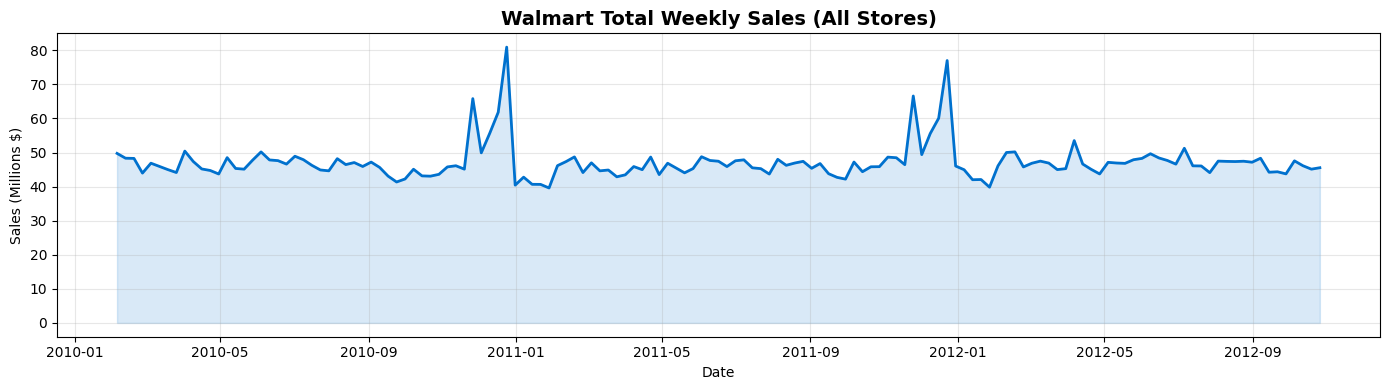

In [32]:
weekly = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
plt.figure(figsize=(14, 4))
plt.plot(weekly['Date'], weekly['Weekly_Sales'] / 1e6, color='#0071CE', linewidth=2)
plt.fill_between(weekly['Date'], weekly['Weekly_Sales'] / 1e6, alpha=0.15, color='#0071CE')#10000000->1.0
plt.title('Walmart Total Weekly Sales (All Stores)', fontsize=14, fontweight='bold')
plt.ylabel('Sales (Millions $)')
plt.xlabel('Date')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/weekly_sales_trend.png', dpi=150)
plt.show()

                 mean   median           sum
Non-Holiday  15901.45  7589.95  6.231919e+09
Holiday      17035.82  7947.74  5.052996e+08

Holiday Weeks:
Date
2011-11-25    3021
2011-12-30    3003
2012-02-10    3001
2012-09-07    2966
2011-09-09    2958
2010-02-12    2956
2010-12-31    2943
2011-02-11    2938
2010-11-26    2938
2010-09-10    2937
Name: count, dtype: int64


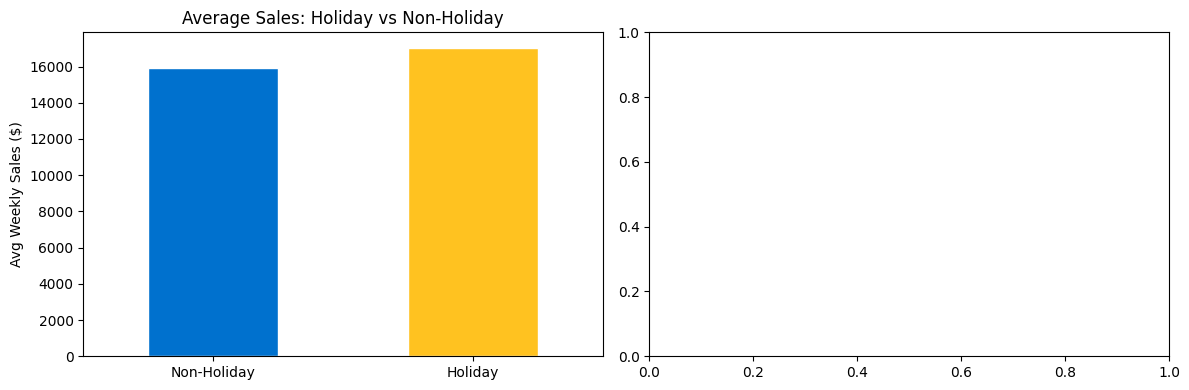

In [33]:
# Holiday impact analysis
holiday_sales = df.groupby('IsHoliday_y')['Weekly_Sales'].agg(['mean','median','sum'])
holiday_sales.index = ['Non-Holiday', 'Holiday']
print(holiday_sales.round(2))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
holiday_sales['mean'].plot(kind='bar', ax=axes[0], color=['#0071CE','#FFC220'], edgecolor='white')
axes[0].set_title('Average Sales: Holiday vs Non-Holiday')
axes[0].set_ylabel('Avg Weekly Sales ($)')
axes[0].tick_params(axis='x', rotation=0)

# Holiday week breakdown
holiday_df = df[df['IsHoliday_y'] == True]
print("\nHoliday Weeks:")
print(holiday_df['Date'].dt.strftime('%Y-%m-%d').value_counts().head(10))
plt.tight_layout()
plt.savefig('holiday_impact.png', dpi=150)
plt.show()

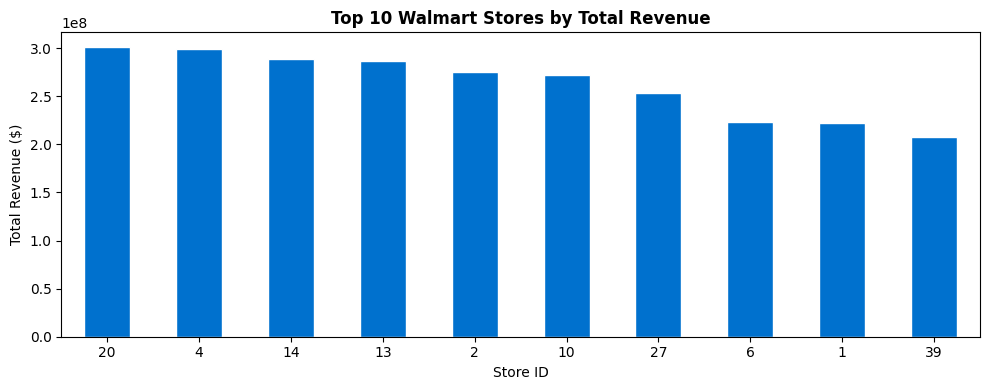


Avg Sales by Store Type:
Type
A    20099.57
B    12237.08
C     9519.53
Name: Weekly_Sales, dtype: float64


In [34]:
# Top 10 stores by revenue
top_stores = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
top_stores.plot(kind='bar', color='#0071CE', edgecolor='white')
plt.title('Top 10 Walmart Stores by Total Revenue', fontweight='bold')
plt.xlabel('Store ID')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('top_stores.png', dpi=150)
plt.show()

# Store type analysis
store_type = df.groupby('Type')['Weekly_Sales'].mean()
print("\nAvg Sales by Store Type:")
print(store_type.round(2))


# Type A = large, Type B = medium, Type C = small
#Here top store id is 20 so Store 20 has heighest revenue

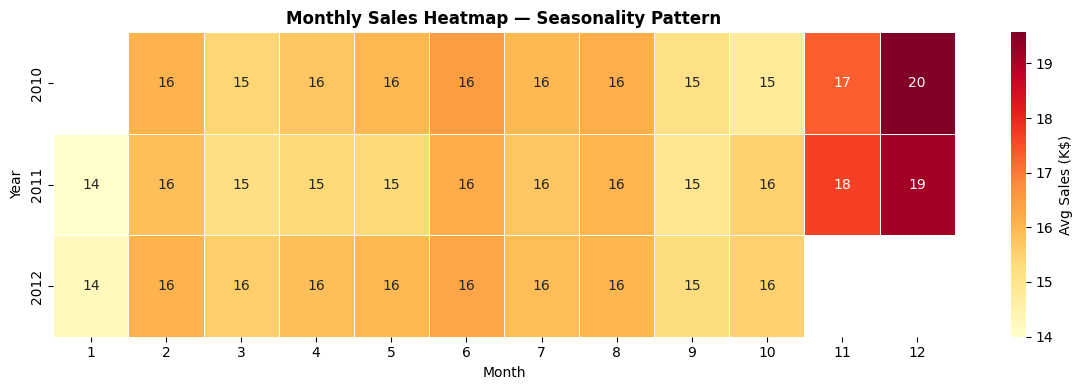

In [35]:
# Monthly seasonality heatmap
pivot = df.groupby(['Year','Month'])['Weekly_Sales'].mean().unstack()

plt.figure(figsize=(12, 4))
sns.heatmap(pivot / 1000, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Avg Sales (K$)'})
plt.title('Monthly Sales Heatmap — Seasonality Pattern', fontweight='bold')
plt.tight_layout()
plt.savefig('seasonality_heatmap.png', dpi=150)
plt.show()


Time series length: 143
Start: 2010-02-05 00:00:00 | End: 2012-10-26 00:00:00


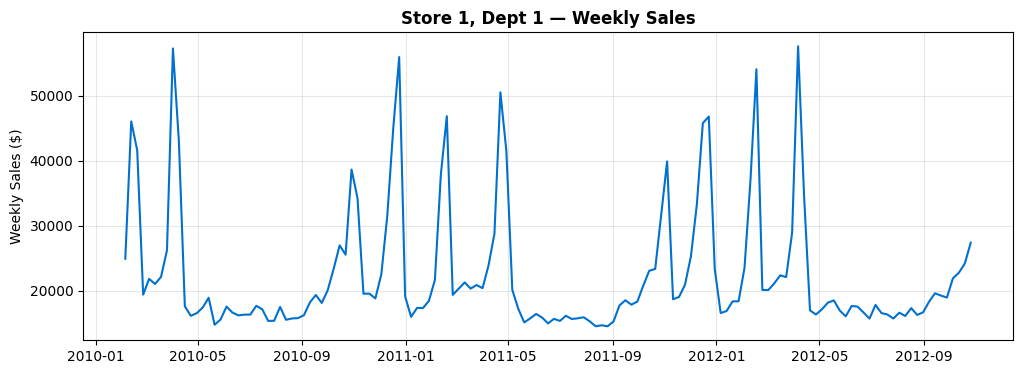

In [36]:
# Focus on Store 1, Dept 1 for modeling
# (Then you can loop all stores later as an upgrade)
store_dept = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy()
store_dept = store_dept.sort_values('Date').set_index('Date')
ts = store_dept['Weekly_Sales']

print("Time series length:", len(ts))
print("Start:", ts.index.min(), "| End:", ts.index.max())

# Plot it
plt.figure(figsize=(12, 4))
plt.plot(ts.index, ts.values, color='#0071CE', linewidth=1.5)
plt.title('Store 1, Dept 1 — Weekly Sales', fontweight='bold')
plt.ylabel('Weekly Sales ($)')
plt.grid(alpha=0.3)
plt.savefig('store1_dept1_ts.png', dpi=150)
plt.show()

**ARIMA Model**

ARIMA — RMSE: 2,670 | MAE: 1,516


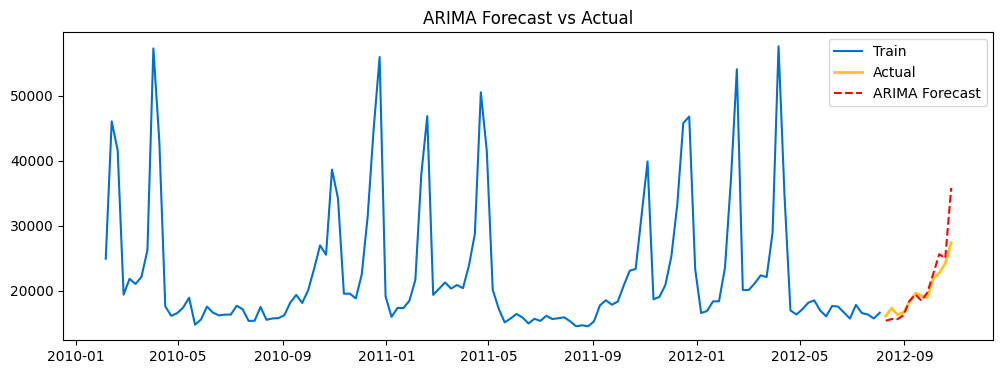

In [37]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Train-test split (last 12 weeks = test)
train_ts = ts[:-12]
test_ts = ts[-12:]

# Fit ARIMA
arima_model = ARIMA(train_ts, order=(1,1,1), seasonal_order=(1,1,0,52))
arima_fit = arima_model.fit()

# Forecast
arima_forecast = arima_fit.forecast(steps=12)

# Evaluate
arima_rmse = np.sqrt(mean_squared_error(test_ts, arima_forecast))
arima_mae = mean_absolute_error(test_ts, arima_forecast)
print(f"ARIMA — RMSE: {arima_rmse:,.0f} | MAE: {arima_mae:,.0f}")

# Plot
plt.figure(figsize=(12, 4))
plt.plot(train_ts.index, train_ts, label='Train', color='#0071CE')
plt.plot(test_ts.index, test_ts, label='Actual', color='#FFC220', linewidth=2)
plt.plot(test_ts.index, arima_forecast, label='ARIMA Forecast', color='red', linestyle='--')
plt.legend()
plt.title('ARIMA Forecast vs Actual')
plt.savefig('arima_forecast.png', dpi=150)
plt.show()

**Prophet Model**

In [38]:
from prophet import Prophet
from prophet.plot import plot_plotly

# Prophet needs 'ds' and 'y' columns
prophet_df = train_ts.reset_index()
prophet_df.columns = ['ds', 'y']

# Add holiday effects (Walmart holiday weeks)
holidays = df[df['IsHoliday_y'] == True][['Date']].drop_duplicates()
holidays.columns = ['ds']
holidays['holiday'] = 'walmart_holiday'
holidays['lower_window'] = -1
holidays['upper_window'] = 1

# Fit Prophet
model = Prophet(
    holidays=holidays,
    yearly_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='multiplicative',  # better for retail
    changepoint_prior_scale=0.05
)
model.fit(prophet_df)

# Forecast 12 weeks ahead
future = model.make_future_dataframe(periods=12, freq='W')
forecast = model.predict(future)

# Evaluate on test period
pred_test = forecast.tail(12)['yhat'].values
prophet_rmse = np.sqrt(mean_squared_error(test_ts, pred_test))
prophet_mae = mean_absolute_error(test_ts, pred_test)
print(f"Prophet — RMSE: {prophet_rmse:,.0f} | MAE: {prophet_mae:,.0f}")
print(f"Improvement over ARIMA: {((arima_rmse - prophet_rmse)/arima_rmse*100):.1f}%")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet — RMSE: 3,643 | MAE: 3,363
Improvement over ARIMA: -36.4%


**Comparison between models**

         Model   RMSE    MAE vs Baseline
Naive Baseline 3502.0 2774.0        0.0%
         ARIMA 2670.0 1516.0      -23.8%
       Prophet 3643.0 3363.0        4.0%


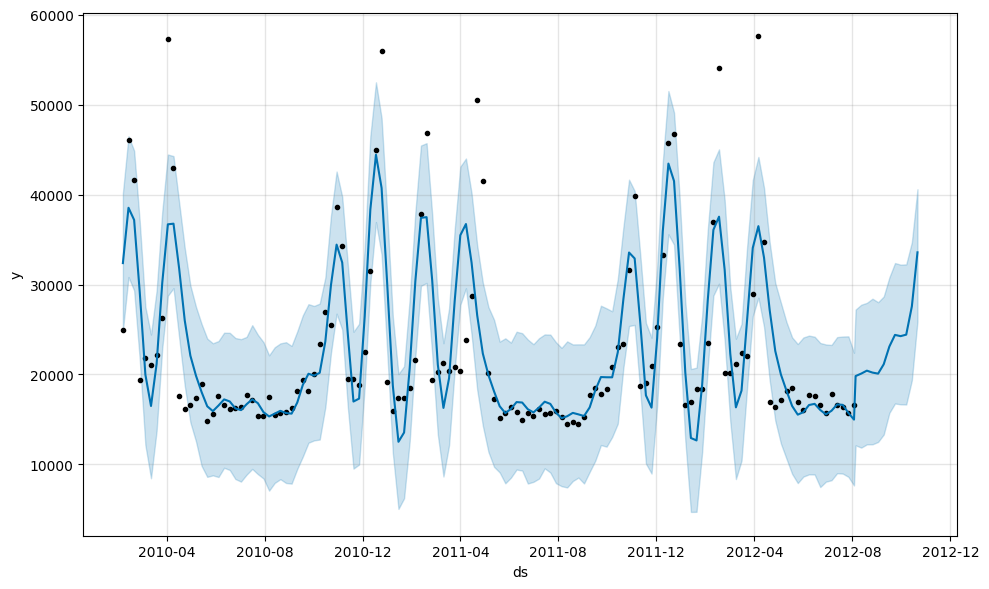

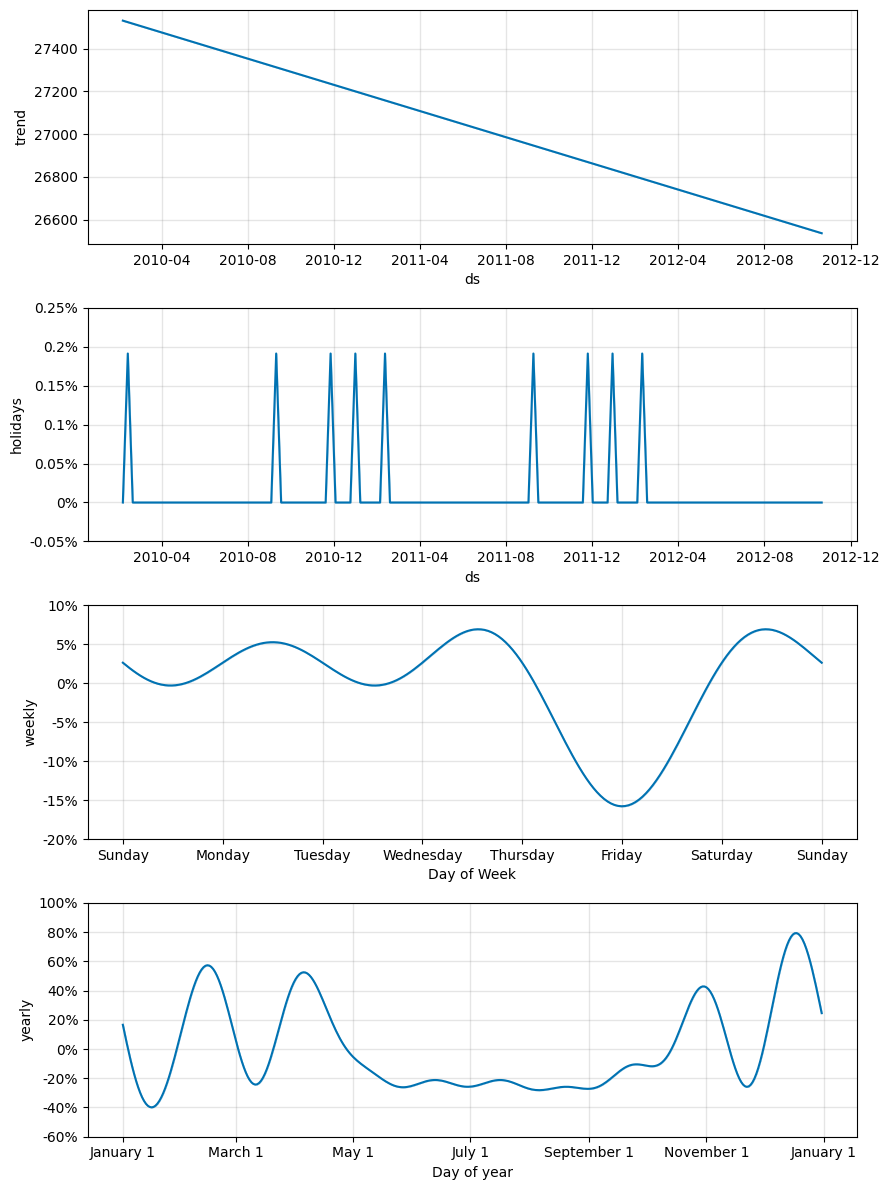

In [39]:
# Final comparison table
import pandas as pd

results = pd.DataFrame({
    'Model': ['Naive Baseline', 'ARIMA', 'Prophet'],
    'RMSE': [
        test_ts.std(),   # naive = predict mean
        arima_rmse,
        prophet_rmse
    ],
    'MAE': [
        abs(test_ts - test_ts.mean()).mean(),
        arima_mae,
        prophet_mae
    ]
})
results['RMSE'] = results['RMSE'].round(0)
results['MAE'] = results['MAE'].round(0)
results['vs Baseline'] = ((results['RMSE'] - results['RMSE'][0]) / results['RMSE'][0] * 100).round(1).astype(str) + '%'
print(results.to_string(index=False))

# Prophet plot
fig1 = model.plot(forecast)
fig1.savefig('prophet_forecast.png', dpi=150)

fig2 = model.plot_components(forecast)
fig2.savefig('prophet_components.png', dpi=150)
# This shows yearly + weekly + holiday

In [41]:
at_risk

,Dept,avg_sales,peak_sales,std_sales,volatility,risk_flag
55,59,694.463564,49196.79,1991.364773,2.867486,True
80,99,415.487065,12550.00,1099.725277,2.646834,True
16,18,7336.943539,120109.74,13837.756895,1.886038,True
53,56,3833.706211,53864.60,5978.350685,1.559418,True
63,78,7.296638,60.00,10.400545,1.425389,True
...,...,...,...,...,...,...
32,34,15625.915402,70060.80,8959.160834,0.573353,True
42,44,4651.729658,27356.30,2584.659873,0.555634,True
76,95,69824.423080,213042.66,38200.536452,0.547094,True
12,13,30663.802634,83784.60,16237.526432,0.529534,True


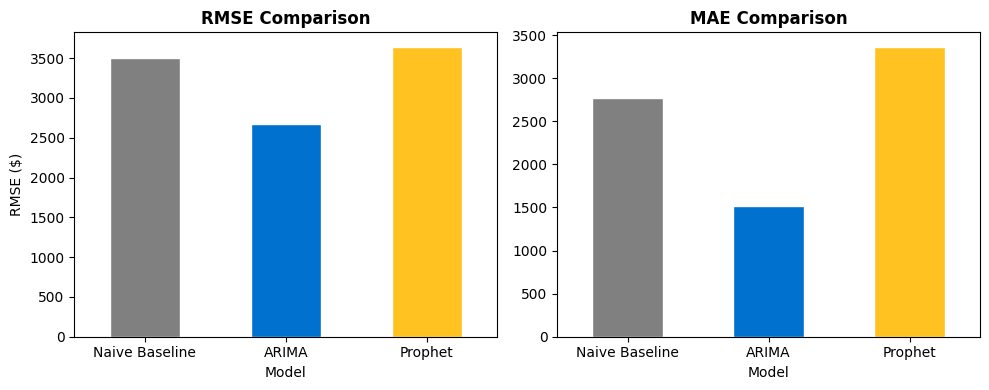

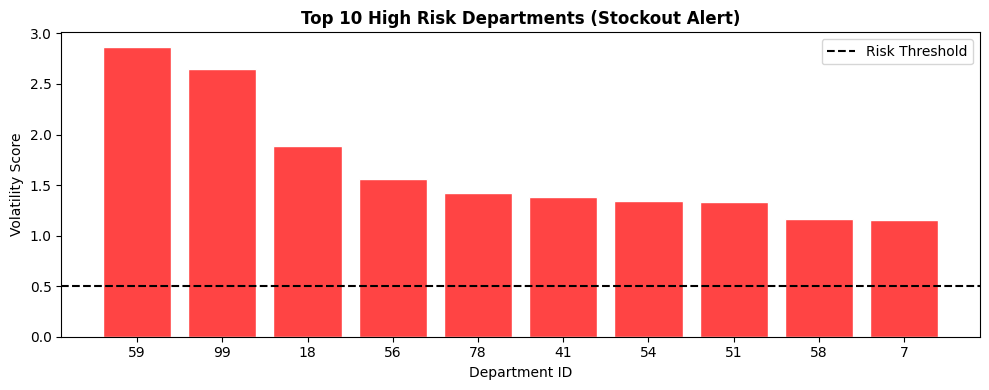

In [42]:
# 1. Model Comparison Chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
results.plot(x='Model', y='RMSE', kind='bar', ax=axes[0],
             color=['gray','#0071CE','#FFC220'], edgecolor='white', legend=False)
axes[0].set_title('RMSE Comparison', fontweight='bold')
axes[0].set_ylabel('RMSE ($)')
axes[0].tick_params(axis='x', rotation=0)

results.plot(x='Model', y='MAE', kind='bar', ax=axes[1],
             color=['gray','#0071CE','#FFC220'], edgecolor='white', legend=False)
axes[1].set_title('MAE Comparison', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# 2. Stockout Risk Chart
plt.figure(figsize=(10, 4))
plt.bar(at_risk.head(10)['Dept'].astype(str),
        at_risk.head(10)['volatility'],
        color='#FF4444', edgecolor='white')
plt.title('Top 10 High Risk Departments (Stockout Alert)', fontweight='bold')
plt.ylabel('Volatility Score')
plt.xlabel('Department ID')
plt.axhline(y=0.5, color='black', linestyle='--', label='Risk Threshold')
plt.legend()
plt.tight_layout()
plt.savefig('stockout_risk.png', dpi=150)
plt.show()

In [43]:
# Identify departments at stockout risk
# A dept is "at risk" if forecast > actual last year's max supply

dept_summary = df.groupby('Dept')['Weekly_Sales'].agg(['mean','max','std']).reset_index()
dept_summary.columns = ['Dept', 'avg_sales', 'peak_sales', 'std_sales']

# Departments where peak exceeds avg by 2x = volatile = stockout risk
dept_summary['volatility'] = dept_summary['std_sales'] / dept_summary['avg_sales']
dept_summary['risk_flag'] = dept_summary['volatility'] > 0.5

at_risk = dept_summary[dept_summary['risk_flag'] == True].sort_values('volatility', ascending=False)
print(f"Departments at Stockout Risk: {len(at_risk)}")
print(at_risk[['Dept','avg_sales','peak_sales','volatility']].head(12).to_string(index=False))

# Export for Power BI
at_risk.to_csv('stockout_risk_departments.csv', index=False)
print("\n💡 Insight: Flag these depts 4 weeks before Q4 for extra stock!")

Departments at Stockout Risk: 76
 Dept    avg_sales  peak_sales  volatility
   59   694.463564    49196.79    2.867486
   99   415.487065    12550.00    2.646834
   18  7336.943539   120109.74    1.886038
   56  3833.706211    53864.60    1.559418
   78     7.296638       60.00    1.425389
   41  1965.559998    42808.15    1.381173
   54   108.305985     1371.00    1.343563
   51    21.931729      209.72    1.328967
   58  3702.907419    44860.00    1.163596
    7 24161.237413   406988.63    1.158264
   16 14245.638270   114476.90    1.126173
    3 11793.698516   131564.25    1.084562

💡 Insight: Flag these depts 4 weeks before Q4 for extra stock!


In [44]:
# Analyze impact of markdown promotions
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

# Fill NaN markdowns with 0 (no markdown)
#important
for col in markdown_cols:
    df[col] = df[col].fillna(0)

# Correlation of each markdown with sales
correlations = {}
for col in markdown_cols:
    corr = df[df[col] > 0][['Weekly_Sales', col]].corr().iloc[0,1]
    correlations[col] = round(corr, 3)

print("Markdown vs Sales Correlation:")
for k, v in sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True):
    bar = "█" * int(abs(v) * 30)
    print(f"  {k}: {v:+.3f}  {bar}")


best_markdown = max(correlations, key=lambda k: abs(correlations[k]))
print(f"\n💡 Most Effective Markdown: {best_markdown} (corr={correlations[best_markdown]})")
print("Recommendation: Prioritize budget on", best_markdown)

Markdown vs Sales Correlation:
  MarkDown5: +0.090  ██
  MarkDown1: +0.085  ██
  MarkDown3: +0.060  █
  MarkDown4: +0.045  █
  MarkDown2: +0.024  

💡 Most Effective Markdown: MarkDown5 (corr=0.09)
Recommendation: Prioritize budget on MarkDown5
